# RUL-prediksjon – C-MAPSS FD001

Mål: forutsi hvor mange sykluser en motor har igjen før svikt (RUL).

**Innhold**
1. Oppsett
2. Last data og legg til RUL
3. Utforsking
4. Forbehandling
5. Baseline-modell
6. Evaluering

## 1. Oppsett

In [8]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from cmapss.data import load_raw, add_rul, plot, nasa_score

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Last data og legg til RUL

RUL = siste syklus for motoren − nåværende syklus, kuttet ved 125 (se `add_rul` i `cmapss/data.py`).

In [9]:
train = add_rul(load_raw("FD001", "train"))
train.head()

,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,125


## 3. Utforsking

### 3.1 Sensorer mot RUL

*TODO: diagram #1 – sensorkurver for noen motorer, RUL på x-aksen.*

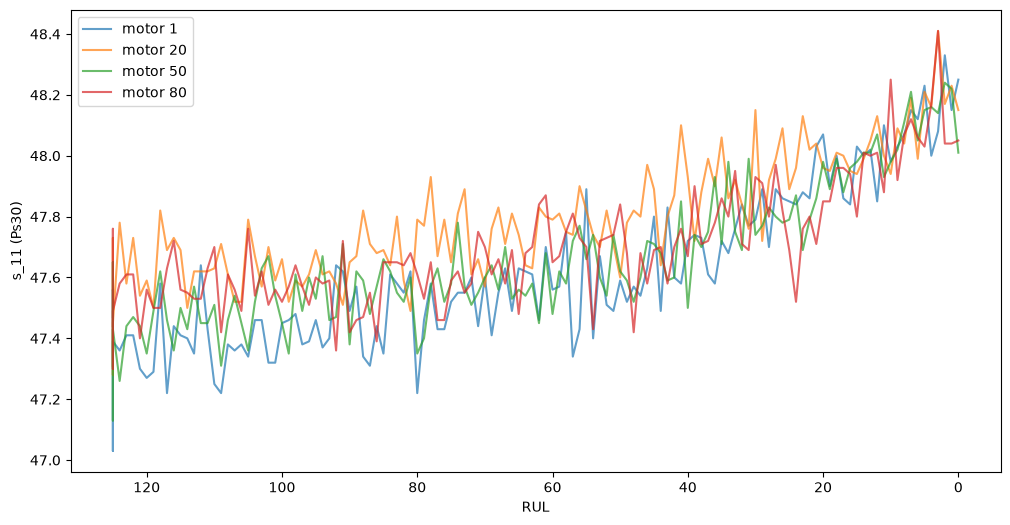

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
for unit in [1, 20, 50, 80]:
    d = train[train.unit_nr == unit]
    ax.plot(d["RUL"], d["s_11"], alpha=0.7, label=f"motor {unit}")
ax.invert_xaxis()          # svikt (RUL=0) til høyre
ax.set_xlabel("RUL"); ax.set_ylabel("s_11 (Ps30)"); ax.legend()


### 3.2 Korrelasjon med RUL

*TODO: diagram #3 – stolpediagram som rangerer sensorene.*

Text(0.5, 1.0, 'Hvilke sensorer følger slitasjen?')

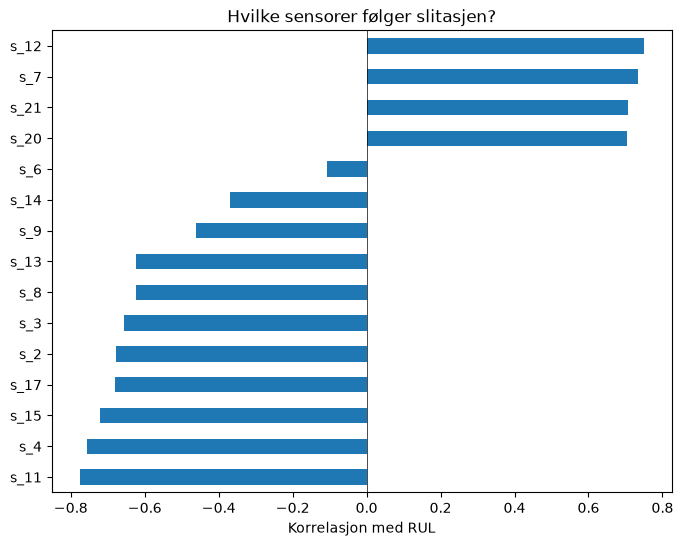

In [11]:
sensorer = [f"s_{i}" for i in range(1, 22)]
levende = [s for s in sensorer if train[s].std() > 1e-6]   # dropp døde sensorer

corr = train[levende].corrwith(train["RUL"]).sort_values()
corr.plot.barh(figsize=(8, 6))
plt.axvline(0, color="k", lw=0.5)
plt.xlabel("Korrelasjon med RUL")
plt.title("Hvilke sensorer følger slitasjen?")


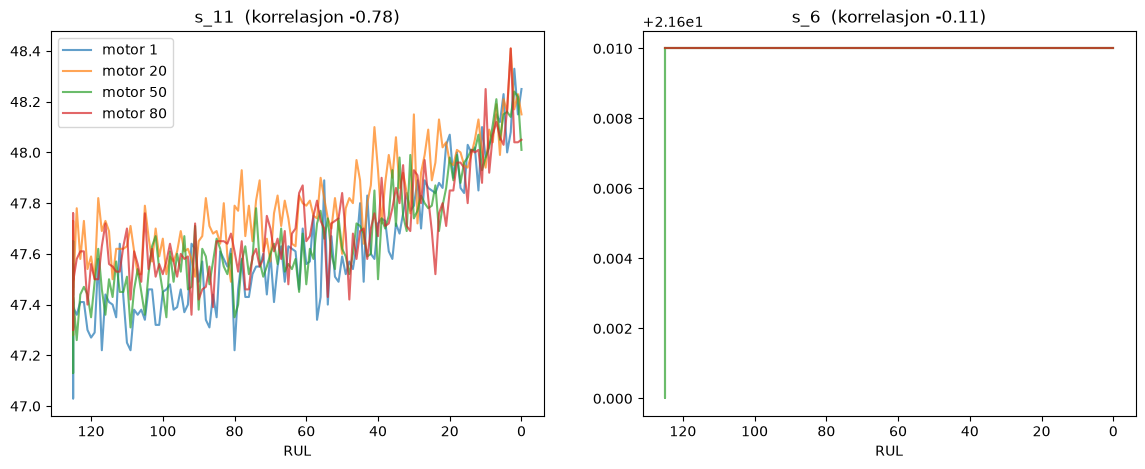

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for ax, s in zip(axes, ["s_11", "s_6"]):
    for unit in [1, 20, 50, 80]:
        d = train[train.unit_nr == unit]
        ax.plot(d["RUL"], d[s], alpha=0.7, label=f"motor {unit}")
    ax.set_title(f"{s}  (korrelasjon {train[s].corr(train['RUL']):.2f})")
    ax.set_xlabel("RUL")
axes[0].invert_xaxis()   # én gang – gjelder begge fordi x-aksen er delt
axes[0].legend()

## 4. Forbehandling



In [13]:
features = ["s_2", "s_3", "s_4", "s_7", "s_8", "s_9", "s_11",
            "s_12", "s_13", "s_14", "s_15", "s_17", "s_20", "s_21"]

X = train[features]
y = train["RUL"]


In [14]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X, y, groups=train["unit_nr"]))

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

val = train.iloc[val_idx]
motorer = val.unit_nr.unique()[:4]


## 5. Baseline-modell

*TODO: `LinearRegression` og `RandomForestRegressor`.*

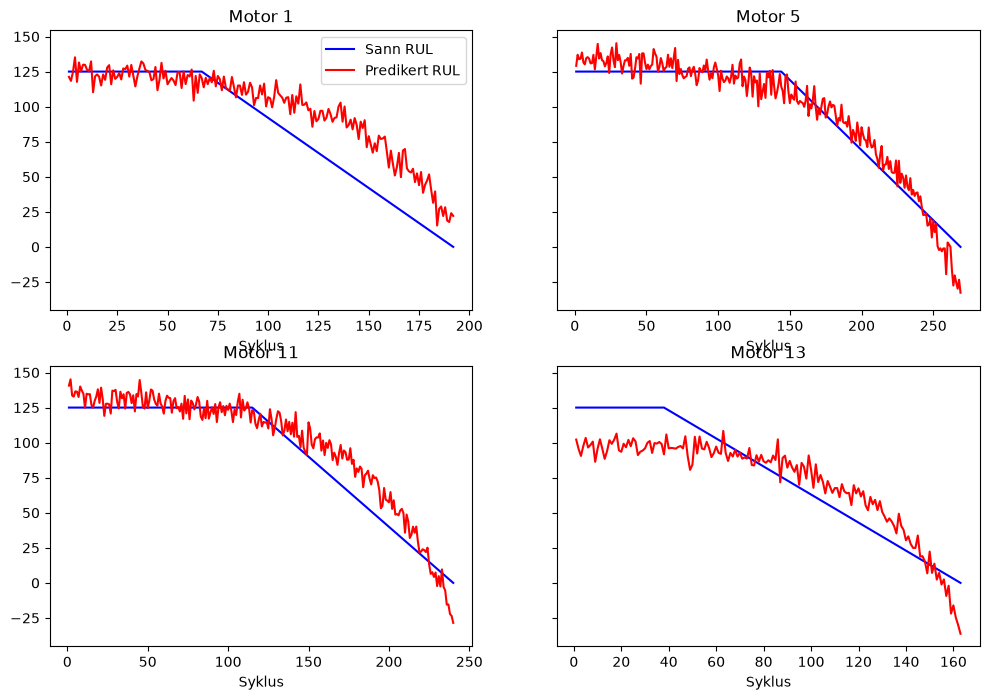

RMSE: 20.4281879725903
R2 0.7601932018909581


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

reg = LinearRegression().fit(X_train, y_train)
y_pred = reg.predict(X_val)

plot(val, y_val, y_pred, motorer)

rmse = mean_squared_error(y_val, y_pred) ** 0.5
r2 = r2_score(y_val, y_pred)

print("RMSE:", rmse)
print("R2", r2)


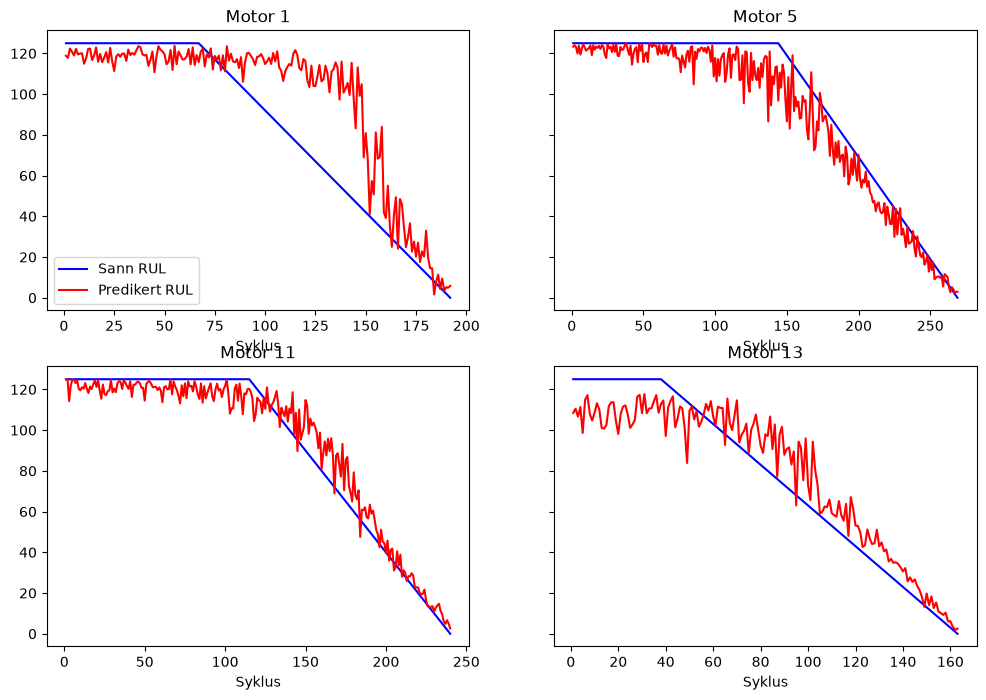

RMSE: 17.17031444263523
R2 0.8305824891309027


In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train, y_train)
y_pred = rf.predict(X_val)

plot(val, y_val, y_pred, motorer)

rmse = mean_squared_error(y_val, y_pred) ** 0.5
r2 = r2_score(y_val, y_pred)

print("RMSE:", rmse)
print("R2", r2)


## 6. Evaluering

*TODO: les testdata + `RUL_FD001.txt`, regn RMSE og NASA-score, plott predikert mot sann RUL.*